NumPy简介3 - 转置与矩阵乘法（文案3对应）
==============

# 第八章：转置操作（.T / transpose / swapaxes / moveaxis）

这一章只关注：**不改变数据内容**，只改变 **维度结构 / 维度顺序**。

## 8.1 转置: `.T`

二维矩阵:

In [ ]:
a = np.arange(6).reshape(2, 3)
print('a.shape  =', a.shape)
print(a)

b = a.T  # 矩阵转置
print('\nb.shape =', b.shape)
print(b)

a.shape  = (2, 3)
[[0 1 2]
 [3 4 5]]

b.shape = (3, 2)
[[0 3]
 [1 4]
 [2 5]]


高维数组:

In [ ]:
x = np.random.rand(2, 3, 4, 5)
y = x.T  # 高维数组：axes 全部反转，因此 y.shape = (5, 4, 3, 2)
print(f"{x.shape=}\n{y.shape=}")

x.shape=(2, 3, 4, 5)
y.shape=(5, 4, 3, 2)


### 8.2 `.T` 等价于 `transpose()`

In [ ]:
c1 = a.T
c2 = np.transpose(a)
print(f"{c1=}\n{c2=}")

c1=array([[0, 3],
       [1, 4],
       [2, 5]])
c2=array([[0, 3],
       [1, 4],
       [2, 5]])


### 8.3 传入 `axes` 参数，指定重排方式
<details>
<summary>查看解释</summary>

原数组`video_nhwc`:
| 维度（axis） | axis=0        | axis=1       | axis=2      | axis=3        |
| -------- | ------------- | ------------ | ----------- | ------------- |
| **size** | 32             | 1080            | 1920           | 3             |
| **语义** | N (批/时间)             | H (高)            | W (宽)           | C (通道)             |

新数组`video_nchw`:
| 新数组维度           | axis=0     | axis=1 | axis=2 | axis=3 |
| --------------- | ---------- | ------ | ------ | ------ |
| **来自原数组的 axis** | 0          | 3      | 1      | 2      |
| **原始 size**     | 32          | 3      | 1080      | 1920      |
| **转置后语义**       | N (批/时间)           | C (通道)      | H (高)      | W (宽)      |

<br/>


**总结: `np.transpose()`中`axes`规则:**

- `axes[i]` 表示：新数组的第 `i` 个 `axis`，来自原数组的哪个 `axis`。

</details>

In [ ]:
video_nhwc = np.random.rand(32, 1080, 1920, 3)            # (N, H, W, C)
print(f"{video_nhwc.shape=}")

video_nchw = np.transpose(video_nhwc, axes=(0, 3, 1, 2))  # (N, C, H, W)
print(f"{video_nchw.shape=}")

video_nhwc.shape=(32, 1080, 1920, 3)
video_nchw.shape=(32, 3, 1080, 1920)


## 8.4 维度调整：swapaxes / moveaxis

### 10.2.1 swapaxes

img.shape        =(600, 800, 3)
img_swapped.shape=(800, 600, 3)


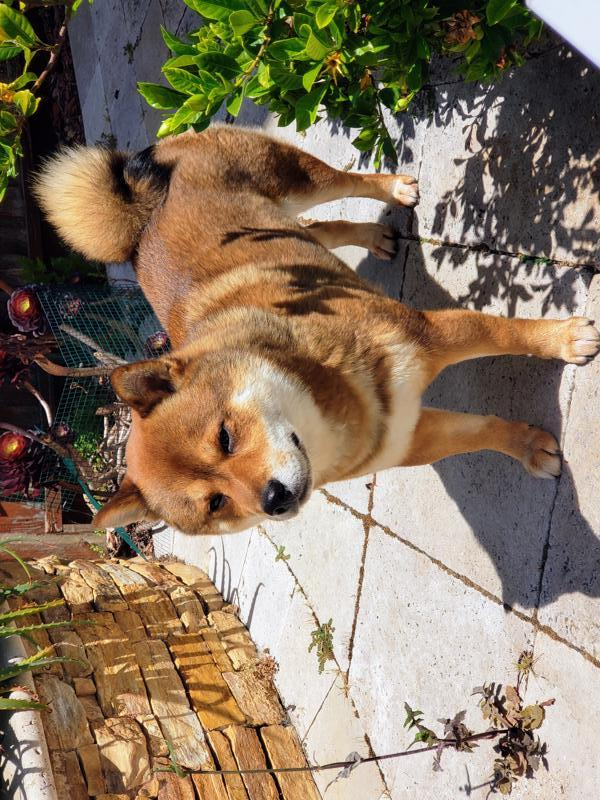

In [ ]:
img_swapped = np.swapaxes(img, 0, 1)
print(f"img.shape        ={img.shape}")
print(f"img_swapped.shape={img_swapped.shape}")
display_image(img_swapped)

### 10.2.2 moveaxis

In [ ]:
video_nhwc = np.random.rand(32, 1080, 1920, 3)  # (N,H,W,C)
video_nchw = np.moveaxis(video_nhwc, 3, 1)      # (N,C,H,W)

print(f"{video_nhwc.shape=}")
print(f"{video_nchw.shape=}")

video_nhwc.shape=(32, 1080, 1920, 3)
video_nchw.shape=(32, 3, 1080, 1920)


---
# 第七章：矩阵乘法（@ / np.matmul）

# 第九章：矩阵乘法（@ / np.matmul）

## 9.1 二维矩阵：传统矩阵乘法

- $C = A \cdot B$
- $C[i, j] = A[i, :] \cdot B[:, j]$

**形状变化**

- $A: (m, n)$  
- $B: (n, p)$  
- $C: (m, p)$


In [ ]:
A = np.arange(6).reshape(2, 3)
B = np.arange(12).reshape(3, 4)
C = A @ B
print(f"{A.shape=}\n{B.shape=}\n{C.shape=}")

A.shape=(2, 3)
B.shape=(3, 4)
C.shape=(2, 4)


In [ ]:
print(f"{A=}\n{B=}\n{C=}")

A=array([[0, 1, 2],
       [3, 4, 5]])
B=array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])
C=array([[20, 23, 26, 29],
       [56, 68, 80, 92]])


## 9.2 高维矩阵：batch 维度广播 + 最后两维矩阵乘法

<details>
<summary>查看解释</summary>

**规则总结：**

- 最后两维做矩阵乘法：`(..., M, K) @ (..., K, N) -> (..., M, N)`
- 前面的维度视为 batch，遵守普通 broadcasting 规则

**例子：**
| | batch 维度（普通广播） | 矩阵维度（matmul 约束） |
|---|---|---|
| X | (6, 5, 4) | (3, 2) |
| Y | (5, 1) | (2, 7) |
| 右对齐后的 Y | (1, 5, 1) | (2, 7) |
| 输出 | (6, 5, 4) | (3, 7) |

</details>

In [ ]:
X = np.zeros((6, 5, 4, 3, 2))
Y = np.zeros((5, 1, 2, 7))
Z = X @ Y
print(f"{X.shape=}\n{Y.shape=   }\n{Z.shape=}")

X.shape=(6, 5, 4, 3, 2)
Y.shape=   (5, 1, 2, 7)
Z.shape=(6, 5, 4, 3, 7)


## 9.3 输入为向量 (不常用)

In [ ]:
# 1. 向量乘向量，结果为内积（点乘）
X = np.arange(3)                   # (3,)
Y = np.ones(3)                     # (3,)
Z = X @ Y                          # ()         # 标量, scalar

In [ ]:
# 2. 向量乘矩阵，向量视为行向量:
X = np.arange(3)                   # (3,)
Y = np.arange(12).reshape(3, 4)    # (3, 4)
Z = X @ Y                          # (4,)       # 输出是行向量，列的维度自动消掉

Y = np.arange(24).reshape(2, 3, 4) # (2, 3, 4)  # Y 是高维，前面为batch
Z = X @ Y                          # (2, 4)

In [ ]:
# 3. 矩阵乘向量，向量视为列向量:
X = np.arange(12).reshape(3, 4)   # (3, 4)
Y = np.arange(4)                  # (4)
Z = X @ Y                         # (3,)        # 输出是列向量，行的维度自动消掉

X = np.arange(24).reshape(2, 3, 4) # (2, 3, 4)  # X 是高维，前面为batch
Z = X @ Y                          # (2, 3)

## 9.4 API 说明：@ 与 np.matmul等价

In [ ]:
print(X @ Y)
print(np.matmul(X, Y))

[[ 14  38  62]
 [ 86 110 134]]
[[ 14  38  62]
 [ 86 110 134]]


---
# 第八章：Reduction 与 Axis